# Exploratory data analysis

## Imports

In [38]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Loading data

In [7]:
customers = pd.read_csv('../data/180601_Customer_Info.csv')
customers

,customer_id,sign_up_date,sign_up_channel
0,2543,2021-04-26,Price Comparison Website
1,2181,2021-07-24,Referral
2,2399,2020-10-11,Bulb Website
3,674,2021-04-04,Referral
4,2332,2021-09-05,Price Comparison Website
...,...,...,...
1694,820,2021-07-17,Referral
1695,1945,2020-12-20,Price Comparison Website
1696,2132,2021-11-29,Bulb Website
1697,2228,2021-10-11,Referral


In [8]:
referrals = pd.read_csv('../data/180601_Referrals_Info.csv')
referrals

,referral_date,referrer_customer_id,sign_up_customer_id
0,2021-07-18,795,1771
1,2021-04-12,577,1510
2,2021-07-07,868,1858
3,2021-10-25,801,1778
4,2021-08-15,690,1637
...,...,...,...
995,2021-07-17,812,1789
996,2021-12-15,156,1031
997,2021-07-20,601,1537
998,2021-07-11,440,1350


## Exploration

### Data types

In [9]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 1699 entries, 0 to 1698
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   customer_id      1699 non-null   int64
 1   sign_up_date     1699 non-null   str  
 2   sign_up_channel  1699 non-null   str  
dtypes: int64(1), str(2)
memory usage: 39.9 KB


In [25]:
customers['sign_up_date'] = pd.to_datetime(customers['sign_up_date'])
# customers.info()

In [26]:
referrals['referral_date'] = pd.to_datetime(referrals['referral_date'])
# referrals.info()

In [23]:
customers['referrer_customer_id'] = customers['customer_id']

### When do members refer?

In [27]:
referrers = referrals.merge(customers, how='inner', on='referrer_customer_id')
referrers

,referral_date,referrer_customer_id,sign_up_customer_id,customer_id,sign_up_date,sign_up_channel
0,2021-07-18,795,1771,795,2021-03-03,Price Comparison Website
1,2021-04-12,577,1510,577,2021-03-28,Price Comparison Website
2,2021-07-07,868,1858,868,2021-03-07,Bulb Website
3,2021-10-25,801,1778,801,2021-04-30,Referral
4,2021-08-15,690,1637,690,2021-07-29,Price Comparison Website
...,...,...,...,...,...,...
827,2021-07-17,448,1359,448,2021-05-27,Referral
828,2021-07-17,812,1789,812,2021-05-02,Price Comparison Website
829,2021-12-15,156,1031,156,2021-03-02,Bulb Website
830,2021-07-20,601,1537,601,2021-04-18,Bulb Website


#### Computing referrer lifetimes 

In [35]:
referrers['lifetime'] = (referrers['referral_date'] - referrers['sign_up_date']).dt.days
referrers

,referral_date,referrer_customer_id,sign_up_customer_id,customer_id,sign_up_date,sign_up_channel,lifetime
0,2021-07-18,795,1771,795,2021-03-03,Price Comparison Website,137
1,2021-04-12,577,1510,577,2021-03-28,Price Comparison Website,15
2,2021-07-07,868,1858,868,2021-03-07,Bulb Website,122
3,2021-10-25,801,1778,801,2021-04-30,Referral,178
4,2021-08-15,690,1637,690,2021-07-29,Price Comparison Website,17
...,...,...,...,...,...,...,...
827,2021-07-17,448,1359,448,2021-05-27,Referral,51
828,2021-07-17,812,1789,812,2021-05-02,Price Comparison Website,76
829,2021-12-15,156,1031,156,2021-03-02,Bulb Website,288
830,2021-07-20,601,1537,601,2021-04-18,Bulb Website,93


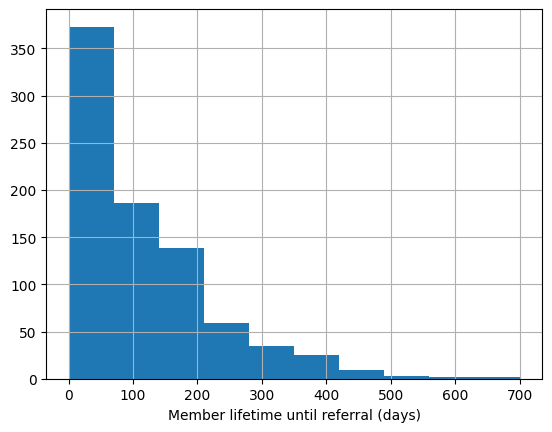

In [46]:
referrers['lifetime'].hist(bins=10)
plt.xlabel('Member lifetime until referral (days)');

In [41]:
referrers['lifetime'].mean()

np.float64(113.65384615384616)

Considering that a lot of members have not been with Bulb for very long, long lifetimes can be considered outliers so the median is a more adequate estimate of when members refer.

In [47]:
print(referrers['lifetime'].median())

83.5
